In [ ]:
# [실습] 회귀 모델링 2 : 은닉층이 있는 회귀 모델

# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler




import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

In [17]:
# device 준비 : cpu, gpu(cuda)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [18]:
### 필요 함수 생성

# 0. 데이터 준비 함수

def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    # train_loader : 학습 데이터 적재하는 놈 => 모델에 데이터 넣어 주는 놈
    # x_val_tensor, y_val_tensor

    return train_loader, x_val_tensor, y_val_tensor


In [19]:
# 1. 학습 함수
# 데이터 로더 -> 학습 -> 예측값 -> 오차를 구한다 (손실함수) -> 옵티마이저(학습), 오차가 최소가 되는 W(가중치) 찾기
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0                                     # 학습시 오차 저장하는 변수
    model.train()                                   # 훈련 모드로 설정, ⭐"학습 해라"가 아니라 설정임
    for x, y in dataloader:     # batch : 현재 배치 번호, (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)           # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결


        # Feed Forward (순전파)
        pred = model(x)                             # x라는 데이터로 순전파 학습, 입력층(32 x 12) -> 출력층(32 x 1) <=예측값
        loss = loss_fn(pred, y)                     # y : 원래답(32,1)
        tr_loss += loss


        # ⭐Loss Backpropagation (오차 역전파), 전파 => 전달
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 ⭐기울기를 계산만 한다.
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 ⭐업데이트
        optimizer.zero_grad()       # 옵티마이저의 ⭐"기울기" 값 초기화. 기울기가 누적되는 것 방지


    tr_loss /= num_batches          # 모든 배치에서의 loss 평균


    return tr_loss.item()

In [20]:
# 2. 평가 함수 : 테스트 데이터로 검증한다. (x_val_tensor, y_val_tensor)

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정


    with torch.no_grad():               # ⭐순전파만 하겠다: 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 학습에 사용했던 손실함수로 예측 값 pred와 실제 값 y 사이의 손실 계산


    return eval_loss, pred          # 오차, 예측값 2개를 돌려준다


In [21]:
# 3. 시각화 함수 : 학습 그래프 그린다
def dl_learning_curve(tr_loss_list, val_loss_list): # tr_loss : 학습 오차, val_loss : 검증 오차
    epochs = list(range(1, len(tr_loss_list)+1)) # 에폭수 : 100
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # plot 점으로 선그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')  # plot 점으로 선그래프


    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [22]:
# 데이터 전처리
# 데이터 로딩 및 준비
# 데이터 로딩

path = 'https://bit.ly/ds_boston_csv'
data = pd.read_csv(path)


# x, y 분할
target = 'medv'
x = data.drop(target, axis = 1) # 이번에는 12개의 입력변수 모두를 이용합니다.
y = data.loc[:, target]


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [23]:
# 데이터 로더
# y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [24]:
# 모델링 : 모델 구조 설계
n_feature = x.shape[1]                          # 컬럼 개수
model2 = nn.Sequential(nn.Linear(n_feature, 2), # 입력 -> 12, 출력 -> 2 <= 입력층
                       nn.ReLU(),               # 활성함수 (선형 -> 비선형 곡선으로 바꿔줌)
                       nn.Linear(2, 1)          # 2,1
                       ).to(device)

In [25]:
# 손실 함수, 옵티마이저 준비
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01)


# 학습
epochs = 1000 # 1000번 반복 학습
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)
    tr_loss_list.append(tr_loss) # learning curve 그리기 위해 리스트에 추가
    val_loss_list.append(val_loss) # learning curve 그리기 위해 리스트에 추가
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 611.169739, val loss : 524.694458
Epoch 2, train loss : 579.827637, val loss : 484.690979
Epoch 3, train loss : 525.777954, val loss : 425.436523
Epoch 4, train loss : 454.545441, val loss : 350.965668
Epoch 5, train loss : 375.235352, val loss : 272.306763
Epoch 6, train loss : 295.349945, val loss : 202.884567
Epoch 7, train loss : 226.098450, val loss : 154.371536
Epoch 8, train loss : 182.880005, val loss : 129.433792
Epoch 9, train loss : 163.034622, val loss : 117.947975
Epoch 10, train loss : 151.758286, val loss : 111.305168
Epoch 11, train loss : 139.211090, val loss : 104.498024
Epoch 12, train loss : 131.560104, val loss : 98.136925
Epoch 13, train loss : 124.004524, val loss : 91.927078
Epoch 14, train loss : 116.609940, val loss : 86.077034
Epoch 15, train loss : 112.319275, val loss : 80.622780
Epoch 16, train loss : 102.931938, val loss : 75.874535
Epoch 17, train loss : 98.457420, val loss : 71.087204
Epoch 18, train loss : 89.888283, val loss : 66

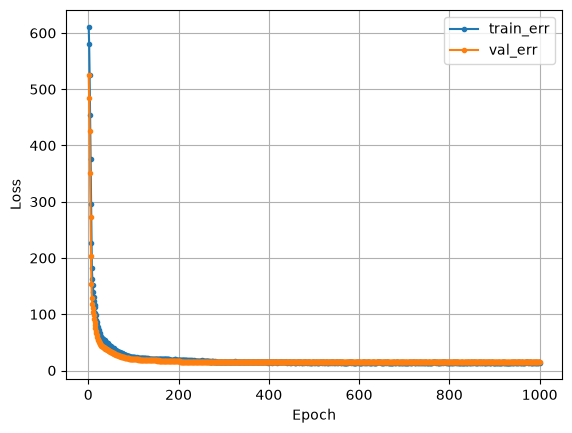

In [26]:
# 시각화 :학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [28]:
# 예측 결과
_, pred = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)


# 모델 평가
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MAE : 2.868312358856201
MAPE : 0.14842426776885986
